# Visualise 3-D Henry Dataset — Input / Output Pairs

Each **scenario** is stored as a single `scenario.npz` containing all runs for a fixed `(beta_c, diffc)` pair.

The tensor layout is detected automatically from the file (`mode` key, or the input channel names for older datasets):

**`split`** (`generate_simple_coupling_scenarios.sh`)
```
input_tensor   : (n_runs, 4, T_in,  nlay, ncol)  — channels: conc, head, beta_c, diffc  over [0, t_split)
output_tensor  : (n_runs, 2, T_out, nlay, ncol)  — channels: conc, head                  over [t_split, T)
```

**`ic_repeat`** (`generate_simple_ic_scenarios.sh`)
```
input_tensor   : (n_runs, 3, T-1, nlay, ncol)  — channels: C0 (repeated), beta_c, diffc
output_tensor  : (n_runs, 2, T-1, nlay, ncol)  — channels: conc, head  over t_1 .. t_{T-1}
```

In both cases the notebook rebuilds the full trajectory `t_0 .. t_{T-1}` per run. The first `n_ctx` frames are the **context** (input) and the rest are the **target**: `n_ctx = t_split` for `split` and `n_ctx = 1` (the IC) for `ic_repeat`. In `ic_repeat` there is no head at t=0, so that frame is left blank.

This notebook visualises a few runs from one scenario:
1. **Metadata** — shapes, grid, time parameters
2. **Spatial snapshots** — concentration and head at selected time indices
3. **Time-series strips** — concentration and head evolving over the full input→output sequence
4. **Run comparison** — same time index across multiple runs (different IC)

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path

# ── Configure path ──────────────────────────────────────────────────────────
# Point this to any dataset produced by generate_simple_coupling_scenarios.sh
# (split) or generate_simple_ic_scenarios.sh (ic_repeat); the layout is
# detected automatically below.
DATA_DIR = Path('~/Projects/groundwater/data/simple_henry_data/').expanduser()
DATASET_NAME = 'grid_scenarios_ic_random_skip2_20x40'
SCENARIO_NPZ = DATA_DIR / DATASET_NAME / 'scenario_012/scenario.npz'

data = np.load(SCENARIO_NPZ, allow_pickle=True)
print('Keys:', list(data.keys()))

Keys: ['input_tensor', 'output_tensor', 'input_channel_names', 'output_channel_names', 'mode', 't_split', 'T_in', 'T_out', 'times_in', 'times_out', 'skip', 'dt_raw', 'dt_eff', 'beta_c', 'diffc', 'al', 'at', 'rho0', 'init_method', 'run_params', 'ncol', 'nlay', 'lx', 'lz', 'total_time', 'nstp', 'scenario_index']


In [28]:
import json
import pandas as pd

def compute_rayleigh_number(beta_c, diffc):
    K=50
    delta_c = 35
    H = 1
    eta = 0.35
    return (K*beta_c*delta_c*H)/(eta*diffc)

manifest_json = DATA_DIR / DATASET_NAME / 'manifest.json'
manifest = json.load(open(manifest_json))
scenario_manifest = manifest['scenarios']
manifest_df = pd.DataFrame(scenario_manifest)

manifest_df['Ra'] = compute_rayleigh_number(manifest_df['beta_c'], manifest_df['diffc'])

In [29]:
# ── Unpack arrays and metadata ───────────────────────────────────────────────
inp  = data['input_tensor']   # (n_runs, C_in,  T_in,  nlay, ncol)
out  = data['output_tensor']  # (n_runs, C_out, T_out, nlay, ncol)

n_runs, C_in,  T_in,  nlay, ncol = inp.shape
_,      C_out, T_out, _,    _    = out.shape

beta_c  = float(data['beta_c'])
diffc   = float(data['diffc'])
t_split = int(data['t_split'])
skip    = int(data['skip'])
dt_eff  = float(data['dt_eff'])
lx      = float(data['lx'])
lz      = float(data['lz'])

times_in  = data['times_in']   # split: (T_in,)   ic_repeat: (1,) = [t_0]
times_out = data['times_out']  # (T_out,)

in_ch  = [s.decode() if isinstance(s, bytes) else str(s) for s in data['input_channel_names']]
out_ch = [s.decode() if isinstance(s, bytes) else str(s) for s in data['output_channel_names']]

# ── Detect the dataset layout ────────────────────────────────────────────────
if 'mode' in data:
    MODE = str(data['mode'])
else:  # datasets generated before the 'mode' key existed
    MODE = 'ic_repeat' if 'concentration_0' in in_ch else 'split'

IN_IDX  = {name: i for i, name in enumerate(in_ch)}
OUT_IDX = {name: i for i, name in enumerate(out_ch)}
CONC_IN = IN_IDX['concentration_0' if MODE == 'ic_repeat' else 'concentration_t']
HEAD_IN = IN_IDX.get('head_t')            # None when head is not an input
CONC_OUT, HEAD_OUT = OUT_IDX['concentration'], OUT_IDX['head']

# Number of context (input) frames in the reconstructed trajectory t_0 .. t_{T-1}
n_ctx = T_in if MODE == 'split' else 1
times_full = np.concatenate([times_in[:n_ctx], times_out])
T_total = len(times_full)

print(f'Mode       : {MODE}')
print(f'Scenario   : beta_c={beta_c}  diffc={diffc}')
print(f'Runs       : {n_runs}')
print(f'Grid       : nlay={nlay}  ncol={ncol}  Lx={lx}m  Lz={lz}m')
print(f'Input      : {inp.shape}   channels: {in_ch}')
print(f'Output     : {out.shape}   channels: {out_ch}')
print(f't_split={t_split}  skip={skip}  dt_eff={dt_eff:.4f} d')
print(f'Trajectory : T={T_total} frames  context={n_ctx}  target={T_out}')
print(f'Context times: [{times_full[0]:.3f}, {times_full[n_ctx - 1]:.3f}] d')
print(f'Target  times: [{times_out[0]:.3f}, {times_out[-1]:.3f}] d')

Mode       : ic_repeat
Scenario   : beta_c=7e-05  diffc=0.03
Runs       : 400
Grid       : nlay=20  ncol=40  Lx=2.0m  Lz=1.0m
Input      : (400, 3, 25, 20, 40)   channels: ['concentration_0', 'beta_c', 'diffc']
Output     : (400, 2, 25, 20, 40)   channels: ['concentration', 'head']
t_split=1  skip=2  dt_eff=0.0400 d
Trajectory : T=26 frames  context=1  target=25
Context times: [0.000, 0.000] d
Target  times: [0.040, 1.000] d


In [30]:
# ── Helpers ──────────────────────────────────────────────────────────────────

CHANNEL_LABELS = {
    'concentration_t': r'$C$ [kg/m³]',
    'concentration_0': r'$C_0$ [kg/m³]',
    'head_t':          r'$h$ [m]',
    'beta_c':          r'$\beta_C$ [m³/kg]',
    'diffc':           r'$D$ [m²/d]',
    'concentration':   r'$C$ [kg/m³]',
    'head':            r'$h$ [m]',
}
CMAPS = {
    'concentration_t': 'RdYlBu_r',
    'concentration_0': 'RdYlBu_r',
    'head_t':          'coolwarm',
    'beta_c':          'Greens',
    'diffc':           'Purples',
    'concentration':   'RdYlBu_r',
    'head':            'coolwarm',
}

# spatial extent for imshow: (left, right, bottom, top)
EXTENT = [0, lx, lz, 0]

def _imshow(ax, field, title, cmap, vmin=None, vmax=None, cbar=True):
    """Plot a 2-D spatial field (nlay x ncol) on ax. NaN cells are left blank."""
    im = ax.imshow(field, origin='upper', aspect='auto',
                   extent=EXTENT, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('x [m]', fontsize=8)
    ax.set_ylabel('z [m]', fontsize=8)
    ax.tick_params(labelsize=7)
    if cbar:
        cb = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
        cb.ax.tick_params(labelsize=7)
    return im


def full_timeseries(run_idx, inp_arr=None, out_arr=None):
    """Rebuild the full trajectory t_0 .. t_{T-1} for a run.

    Returns conc (T, nlay, ncol), head (T, nlay, ncol) and times (T,).
    The first n_ctx frames come from the input (context), the rest from the
    output (target). In ic_repeat mode head at t=0 is not stored, so that
    frame is NaN.

    inp_arr / out_arr default to the loaded scenario; pass another scenario's
    input_tensor / output_tensor (same dataset) to reuse the same layout.
    """
    inp_arr = inp if inp_arr is None else inp_arr
    out_arr = out if out_arr is None else out_arr
    conc_ctx = inp_arr[run_idx, CONC_IN, :n_ctx]
    if HEAD_IN is not None:
        head_ctx = inp_arr[run_idx, HEAD_IN, :n_ctx]
    else:
        head_ctx = np.full_like(conc_ctx, np.nan)
    conc = np.concatenate([conc_ctx, out_arr[run_idx, CONC_OUT]], axis=0)
    head = np.concatenate([head_ctx, out_arr[run_idx, HEAD_OUT]], axis=0)
    return conc, head, times_full


def phase_label(tidx):
    return 'INPUT' if tidx < n_ctx else 'TARGET'


def _sci_tex(x):
    """5e-06 -> '5\\times10^{-6}', 0.001 -> '10^{-3}' (mathtext, no $)."""
    if x == 0:
        return '0'
    exp = int(np.floor(np.log10(abs(x)) + 1e-9))
    mant = x / 10**exp
    return f'10^{{{exp}}}' if np.isclose(mant, 1) else f'{mant:.2g}\\times10^{{{exp}}}'

## 1 · Spatial snapshots at selected time steps

For a chosen run, plot concentration and head at a few time indices spanning the
full sequence: **initial condition**, **last input step** (split only), and points through the **target** window.

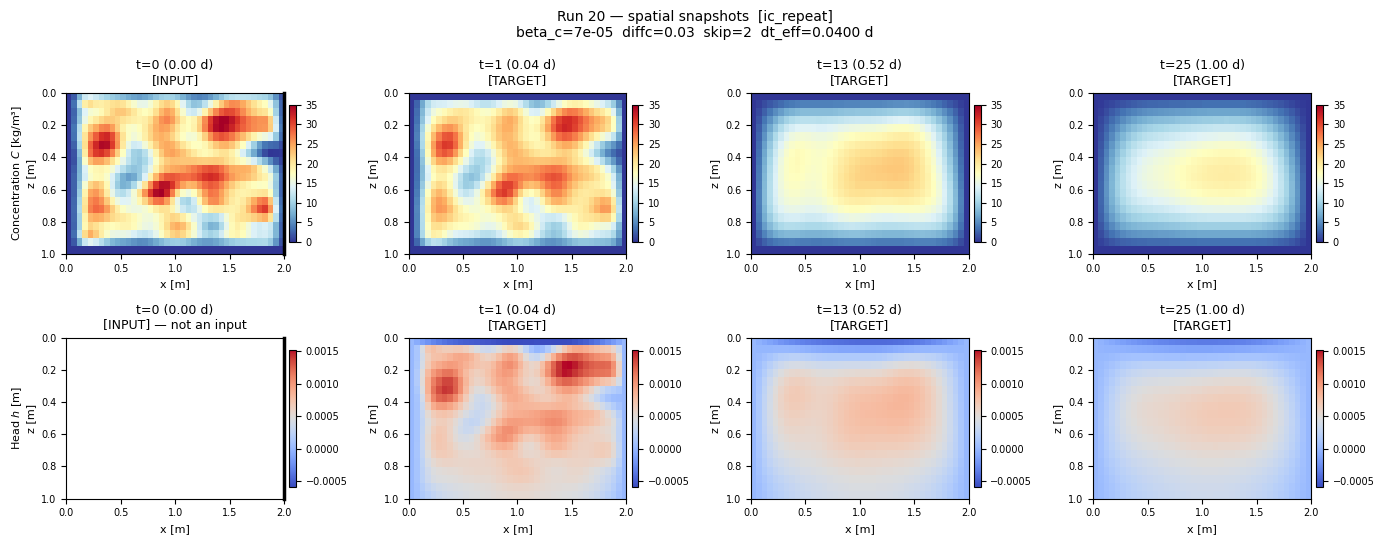

In [31]:
RUN_IDX = 20   # which run to inspect

conc_full, head_full, times_full = full_timeseries(RUN_IDX)

# Pick time indices: t=0, middle/last context step, first/middle/last target step
snapshot_indices = sorted(set([
    0,
    n_ctx // 2,
    n_ctx - 1,
    n_ctx,
    n_ctx + T_out // 2,
    T_total - 1,
]))
# Trim to valid range
snapshot_indices = [i for i in snapshot_indices if 0 <= i < T_total]

n_snaps = len(snapshot_indices)
fig, axes = plt.subplots(2, n_snaps, figsize=(3.5 * n_snaps, 5.5))
fig.suptitle(
    f'Run {RUN_IDX} — spatial snapshots  [{MODE}]\n'
    f'beta_c={beta_c}  diffc={diffc}  skip={skip}  dt_eff={dt_eff:.4f} d',
    fontsize=10,
)

# Shared colour limits across time for each field (ignore missing head at t=0)
c_vmin, c_vmax = float(np.nanmin(conc_full)), float(np.nanmax(conc_full))
h_vmin, h_vmax = float(np.nanmin(head_full)), float(np.nanmax(head_full))

for col, tidx in enumerate(snapshot_indices):
    title = f't={tidx} ({times_full[tidx]:.2f} d)\n[{phase_label(tidx)}]'
    _imshow(axes[0, col], conc_full[tidx], title, 'RdYlBu_r', c_vmin, c_vmax)
    head_title = title if not np.all(np.isnan(head_full[tidx])) else title + ' — not an input'
    _imshow(axes[1, col], head_full[tidx], head_title, 'coolwarm', h_vmin, h_vmax)

axes[0, 0].set_ylabel(r'Concentration $C$ [kg/m³]' + '\nz [m]', fontsize=8)
axes[1, 0].set_ylabel(r'Head $h$ [m]' + '\nz [m]', fontsize=8)

# Draw a vertical separator between input and output panels
last_input_col = sum(1 for i in snapshot_indices if i < n_ctx) - 1
for row in range(2):
    axes[row, last_input_col].spines['right'].set_linewidth(2.5)
    axes[row, last_input_col].spines['right'].set_color('black')

plt.tight_layout()
plt.show()

## 2 · Time-strip: full temporal evolution for one run

The time strip for one run in the loaded scenario, with concentration in the top row and head in the bottom row. Each row has its own colour scale, shared across time.
The input frames are separated from the target frames by a wider gap. In `ic_repeat` head is not stored at t=0, so that frame is left blank.
Set `FRAME_STRIDE = 1` to show every frame or `2` for every other frame. As in 2b, the title is printed above the plot rather than drawn on it, so the figure can go straight into a paper.

Run 10 — time strip (6 frames, every 5 step(s))  [ic_repeat]
  beta_c=7e-05  diffc=0.03  Ra=11.7
  IC: type=grf, len_scale=0.1, var=0.1
  First 1 frame(s) = INPUT, separated by a wider gap from the TARGET



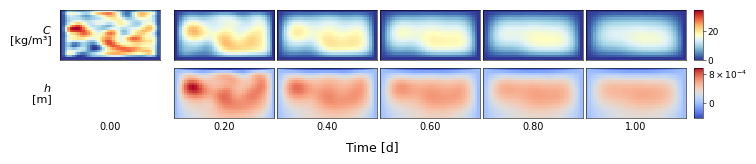

In [32]:
RUN_IDX      = 10
FRAME_STRIDE = 5   # 1 = every frame, 2 = every other frame (half)

conc_full, head_full, times_full = full_timeseries(RUN_IDX)
frame_idx = np.arange(0, T_total, FRAME_STRIDE)
n_fr = len(frame_idx)
n_in = int(np.sum(frame_idx < n_ctx))   # frames that are model input

run_meta = json.loads(str(data['run_params'][RUN_IDX]))
ic_desc = ', '.join(
    f'{k.replace("random_field_", "")}={run_meta[k]}'
    for k in ('random_field_type', 'random_field_len_scale', 'random_field_var')
    if k in run_meta
)
print(
    f'Run {RUN_IDX} — time strip ({n_fr} frames, every {FRAME_STRIDE} step(s))  [{MODE}]\n'
    f'  beta_c={beta_c}  diffc={diffc}  Ra={compute_rayleigh_number(beta_c, diffc):.3g}\n'
    f'  IC: {ic_desc}'
    + (f'\n  First {n_in} frame(s) = INPUT, separated by a wider gap from the TARGET' if n_in else '')
    + '\n'
)

# ── Layout, all in inches: one axes per frame, physical aspect ratio ────────
FW      = 1.0 if n_fr <= 14 else 0.55   # frame width
FH      = FW * lz / lx                  # frame height
GAP     = 0.03                          # gap between frames
IN_GAP  = 0.14                          # gap between input and target frames
ROW_GAP = 0.08
LEFT, RIGHT, BOTTOM, TOP = 0.6, 0.55, 0.36, 0.05
CB_PAD, CB_W = 0.08, 0.09

x0 = [k * (FW + GAP) + (IN_GAP - GAP if 0 < n_in <= k else 0) for k in range(n_fr)]
frames_w = x0[-1] + FW
rows_h   = 2 * FH + ROW_GAP
W, H = LEFT + frames_w + RIGHT, BOTTOM + rows_h + TOP
fig = plt.figure(figsize=(W, H))
add_ax = lambda x, y, w, h: fig.add_axes([x / W, y / H, w / W, h / H])

# Each field gets its own colour scale, shared across time
for r, (field, label, cmap) in enumerate([
    (conc_full, '$C$\n[kg/m³]', 'RdYlBu_r'),
    (head_full, '$h$\n[m]',     'coolwarm'),
]):
    y = BOTTOM + (1 - r) * (FH + ROW_GAP)
    vmin, vmax = float(np.nanmin(field[frame_idx])), float(np.nanmax(field[frame_idx]))
    for k, tidx in enumerate(frame_idx):
        ax = add_ax(LEFT + x0[k], y, FW, FH)
        ax.set_xticks([])
        ax.set_yticks([])
        if r == 1:
            ax.set_xlabel(f'{times_full[tidx]:.2f}', fontsize=7, labelpad=3)
        if np.all(np.isnan(field[tidx])):   # head at t=0 is not stored in ic_repeat
            for spine in ax.spines.values():
                spine.set_visible(False)
            continue
        im = ax.imshow(field[tidx], cmap=cmap, vmin=vmin, vmax=vmax,
                       aspect='auto', interpolation='nearest')
        for spine in ax.spines.values():
            spine.set_linewidth(0.4)
    fig.text((LEFT - 0.08) / W, (y + FH / 2) / H, label,
             fontsize=8, linespacing=1.1, ha='right', va='center')

    cb = fig.colorbar(im, cax=add_ax(LEFT + frames_w + CB_PAD, y, CB_W, FH))
    cb.locator = plt.MaxNLocator(2)
    if r == 1:
        cb.formatter = plt.FuncFormatter(lambda v, _: f'${_sci_tex(v)}$')
    cb.update_ticks()
    cb.ax.tick_params(labelsize=6.5, width=0.4, length=2, pad=1.5)
    cb.outline.set_linewidth(0.4)

fig.text((LEFT + frames_w / 2) / W, 0.0, 'Time [d]',
         fontsize=9, ha='center', va='bottom')

fig.savefig(SCENARIO_NPZ.parent / f'run{RUN_IDX}_timestrip.png', dpi=300, bbox_inches='tight')

plt.show()

In [26]:
SCENARIO_NPZ.parent / f'run{RUN_IDX}_timestrip.png'

PosixPath('/Users/akap5486/Projects/groundwater/data/simple_henry_data/grid_scenarios_ic_random_skip2_20x40/scenario_012/run10_timestrip.png')

## 2b · Time-strip comparison across scenarios

The same time strip for one run index in six scenarios: {min, mid, max} `beta_c` × {min, max} `diffc`, selected from the dataset manifest.
Each row is labelled with its Rayleigh number. Concentration uses one colour scale across all rows. Head magnitude scales with `beta_c`, so each head row has its own colour scale.
Set `FRAME_STRIDE = 1` to show every frame or `2` for every other frame. Figure titles are printed above the plots rather than drawn on them, so the figures can go straight into a paper.

The initial fields are not seeded, so the same run index has the same random-field statistics (type, length scale, variance) in every scenario but an independent realisation.

concentration — run 12 across scenarios (7 frames, every 4 step(s))  [ic_repeat]
  IC: type=grf, len_scale=0.1, var=0.1 (same statistics, independent realisation per scenario)
  First 1 frame(s) = INPUT, separated by a wider gap from the TARGET



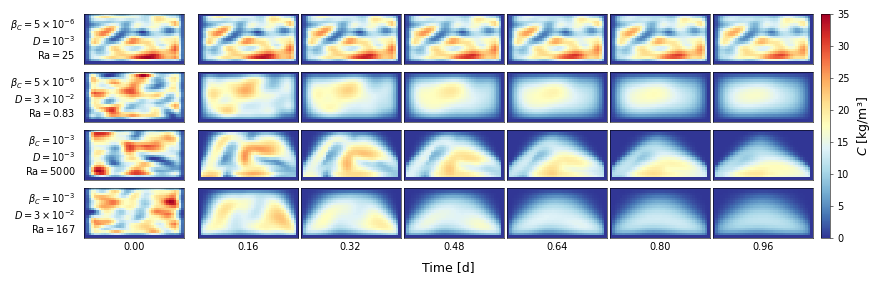

head — run 12 across scenarios (6 frames, every 4 step(s))  [ic_repeat]
  IC: type=grf, len_scale=0.1, var=0.1 (same statistics, independent realisation per scenario)



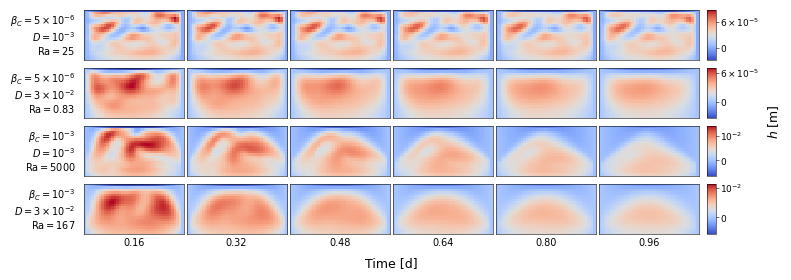

In [8]:
RUN_IDX      = 12
FRAME_STRIDE = 4   # 1 = every frame, 2 = every other frame (half)

# ── Select scenarios: {min, mid, max} beta_c × {min, max} diffc ─────────────
betas  = np.sort(manifest_df['beta_c'].unique())
diffcs = np.sort(manifest_df['diffc'].unique())
sel_betas  = list(dict.fromkeys([betas[0], betas[-1]]))
sel_diffcs = list(dict.fromkeys([diffcs[0], diffcs[-1]]))

sel = [
    manifest_df[(manifest_df['beta_c'] == b) & (manifest_df['diffc'] == dc)].iloc[0]
    for b in sel_betas for dc in sel_diffcs
]

# ── Frames per field: head is not stored at t=0 in ic_repeat, so skip those ──
frame_idx = np.arange(0, T_total, FRAME_STRIDE)
frames = {
    'concentration': frame_idx,
    'head': frame_idx if HEAD_IN is not None else frame_idx[frame_idx >= n_ctx],
}

# ── Load the same run index from each scenario ──────────────────────────────
series = {'concentration': [], 'head': []}   # per scenario: (n_frames, nlay, ncol)
for row in sel:
    d = np.load(DATA_DIR / DATASET_NAME / row['scenario'] / 'scenario.npz')
    conc_s, head_s, _ = full_timeseries(RUN_IDX, d['input_tensor'], d['output_tensor'])
    series['concentration'].append(conc_s[frames['concentration']])
    series['head'].append(head_s[frames['head']])

run_meta = json.loads(str(data['run_params'][RUN_IDX]))
ic_desc = ', '.join(
    f'{k.replace("random_field_", "")}={run_meta[k]}'
    for k in ('random_field_type', 'random_field_len_scale', 'random_field_var')
    if k in run_meta
)


def _row_label(row):
    ra = row['Ra']
    ra_str = f'{ra:.0f}' if ra >= 10 else f'{ra:.2g}'
    return (f"$\\beta_C={_sci_tex(row['beta_c'])}$\n"
            f"$D={_sci_tex(row['diffc'])}$\n"
            f"Ra$={ra_str}$")


# ── Layout, all in inches: one axes per frame, physical aspect ratio ────────
FW      = 1.0 if len(frame_idx) <= 14 else 0.55   # frame width
FH      = FW * lz / lx                            # frame height
GAP     = 0.03                                    # gap between frames
IN_GAP  = 0.14                                    # gap between input and target frames
ROW_GAP = max(0.08, 0.44 - FH)                    # room for the 3-line row labels
LEFT, RIGHT, BOTTOM, TOP = 0.85, 0.85, 0.36, 0.05
CB_PAD, CB_W = 0.08, 0.09

# Concentration shares one colour scale (and colourbar) across scenarios; head
# magnitude scales with beta_c, so each scenario gets its own head colour scale.
for field, label, cmap, shared_scale in [
    ('concentration', r'$C$ [kg/m³]', 'RdYlBu_r', True),
    ('head',          r'$h$ [m]',     'coolwarm', False),
]:
    fidx   = frames[field]
    n_fr   = len(fidx)
    n_in   = int(np.sum(fidx < n_ctx))            # frames that are model input
    n_rows = len(sel)
    print(
        f'{field} — run {RUN_IDX} across scenarios ({n_fr} frames, every '
        f'{FRAME_STRIDE} step(s))  [{MODE}]\n'
        f'  IC: {ic_desc} (same statistics, independent realisation per scenario)'
        + (f'\n  First {n_in} frame(s) = INPUT, separated by a wider gap from the TARGET' if n_in else '')
        + '\n'
    )

    x0 = [k * (FW + GAP) + (IN_GAP - GAP if 0 < n_in <= k else 0) for k in range(n_fr)]
    frames_w = x0[-1] + FW
    rows_h   = n_rows * FH + (n_rows - 1) * ROW_GAP
    W, H = LEFT + frames_w + RIGHT, BOTTOM + rows_h + TOP
    fig = plt.figure(figsize=(W, H))
    add_ax = lambda x, y, w, h: fig.add_axes([x / W, y / H, w / W, h / H])

    vmin = float(np.nanmin(series[field])) if shared_scale else None
    vmax = float(np.nanmax(series[field])) if shared_scale else None

    for r, (row, fr) in enumerate(zip(sel, series[field])):
        y = BOTTOM + (n_rows - 1 - r) * (FH + ROW_GAP)
        lo = vmin if shared_scale else float(np.nanmin(fr))
        hi = vmax if shared_scale else float(np.nanmax(fr))
        for k, tidx in enumerate(fidx):
            ax = add_ax(LEFT + x0[k], y, FW, FH)
            im = ax.imshow(fr[k], cmap=cmap, vmin=lo, vmax=hi,
                           aspect='auto', interpolation='nearest')
            ax.set_xticks([])
            ax.set_yticks([])
            for spine in ax.spines.values():
                spine.set_linewidth(0.4)
            if r == n_rows - 1:
                ax.set_xlabel(f'{times_full[tidx]:.2f}', fontsize=7, labelpad=3)
        fig.text((LEFT - 0.08) / W, (y + FH / 2) / H, _row_label(row),
                 fontsize=7, linespacing=1.1, ha='right', va='center')

        if not shared_scale:
            cb = fig.colorbar(im, cax=add_ax(LEFT + frames_w + CB_PAD, y, CB_W, FH))
            cb.locator = plt.MaxNLocator(2)
            cb.formatter = plt.FuncFormatter(lambda v, _: f'${_sci_tex(v)}$')
            cb.update_ticks()
            cb.ax.tick_params(labelsize=6.5, width=0.4, length=2, pad=1.5)
            cb.outline.set_linewidth(0.4)

    if shared_scale:
        cb = fig.colorbar(im, cax=add_ax(LEFT + frames_w + CB_PAD, BOTTOM, CB_W, rows_h))
        cb.set_label(label, fontsize=9)
        cb.ax.tick_params(labelsize=7, width=0.4, length=2)
        cb.outline.set_linewidth(0.4)
    else:
        fig.text((W - 0.1) / W, (BOTTOM + rows_h / 2) / H, label,
                 fontsize=9, rotation=90, ha='center', va='center')

    fig.text((LEFT + frames_w / 2) / W, 0.0, 'Time [d]',
             fontsize=9, ha='center', va='bottom')

    fig.savefig(DATA_DIR / DATASET_NAME / f'run{RUN_IDX}_{field}_scenarios.png', dpi=300, bbox_inches='tight')

    plt.show()

## 3 · Input channels at t = 0 for one run

Shows every input channel at the first input time index:
`concentration`, `head`, `beta_c`, `diffc` for `split`, and `C0`, `beta_c`, `diffc` for `ic_repeat`.

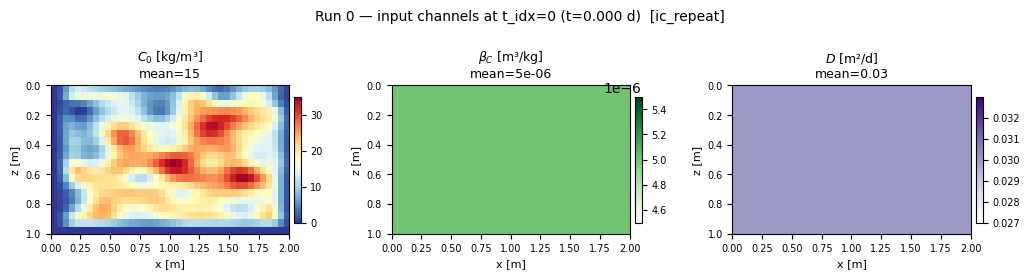

In [37]:
RUN_IDX = 0
T_IDX   = 0   # time index within the input window

fig, axes = plt.subplots(1, C_in, figsize=(3.5 * C_in, 2.8))
axes = np.atleast_1d(axes)
fig.suptitle(
    f'Run {RUN_IDX} — input channels at t_idx={T_IDX} '
    f'(t={times_full[min(T_IDX, n_ctx - 1)]:.3f} d)  [{MODE}]',
    fontsize=10,
)

for ch, ax in enumerate(axes):
    name  = in_ch[ch]
    field = inp[RUN_IDX, ch, T_IDX]   # (nlay, ncol)
    label = CHANNEL_LABELS.get(name, name)
    cmap  = CMAPS.get(name, 'viridis')
    _imshow(ax, field, f'{label}\nmean={field.mean():.3g}', cmap)

plt.tight_layout()
plt.show()

## 4 · Context / target boundary

A focused three-panel view:
- **`split`**: IC (t=0), last input step (t=T_in-1, the last step the model sees), first target step (t=T_in).
- **`ic_repeat`**: IC (t=0, the only thing the model sees), first target step, last target step.

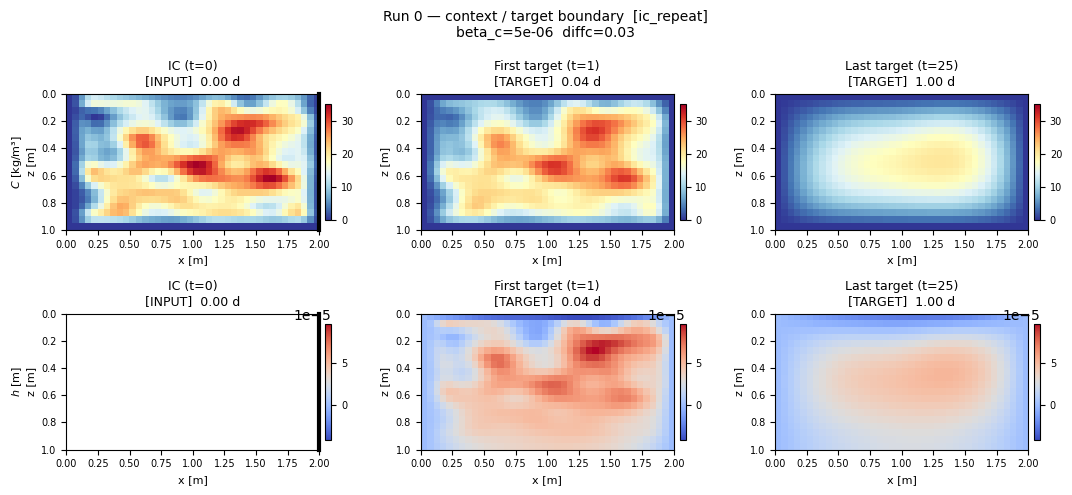

In [38]:
RUN_IDX = 0

conc_full, head_full, times_full = full_timeseries(RUN_IDX)

if n_ctx > 1:
    panels = [
        (0,         'IC (t=0)\n[INPUT]'),
        (n_ctx - 1, f'Last input (t={n_ctx - 1})\n[INPUT]'),
        (n_ctx,     f'First target (t={n_ctx})\n[TARGET]'),
    ]
else:
    panels = [
        (0,           'IC (t=0)\n[INPUT]'),
        (1,           'First target (t=1)\n[TARGET]'),
        (T_total - 1, f'Last target (t={T_total - 1})\n[TARGET]'),
    ]
last_input_col = sum(1 for tidx, _ in panels if tidx < n_ctx) - 1

c_vmin, c_vmax = float(np.nanmin(conc_full)), float(np.nanmax(conc_full))
h_vmin, h_vmax = float(np.nanmin(head_full)), float(np.nanmax(head_full))

fig, axes = plt.subplots(2, 3, figsize=(11, 5))
fig.suptitle(
    f'Run {RUN_IDX} — context / target boundary  [{MODE}]\n'
    f'beta_c={beta_c}  diffc={diffc}',
    fontsize=10,
)

for col, (tidx, title) in enumerate(panels):
    title = f'{title}  {times_full[tidx]:.2f} d'
    _imshow(axes[0, col], conc_full[tidx], title, 'RdYlBu_r', c_vmin, c_vmax)
    _imshow(axes[1, col], head_full[tidx], title, 'coolwarm',  h_vmin, h_vmax)

axes[0, 0].set_ylabel(r'$C$ [kg/m³]' + '\nz [m]', fontsize=8)
axes[1, 0].set_ylabel(r'$h$ [m]' + '\nz [m]', fontsize=8)

# Highlight the boundary
for row in range(2):
    axes[row, last_input_col].spines['right'].set_linewidth(3)
    axes[row, last_input_col].spines['right'].set_color('black')

plt.tight_layout()
plt.show()

## 5 · Run comparison — same time index, different initial conditions

Shows the concentration IC (t=0) for several runs side-by-side,
illustrating how the random initial field varies between runs within
the same scenario (same `beta_c`, `diffc`).

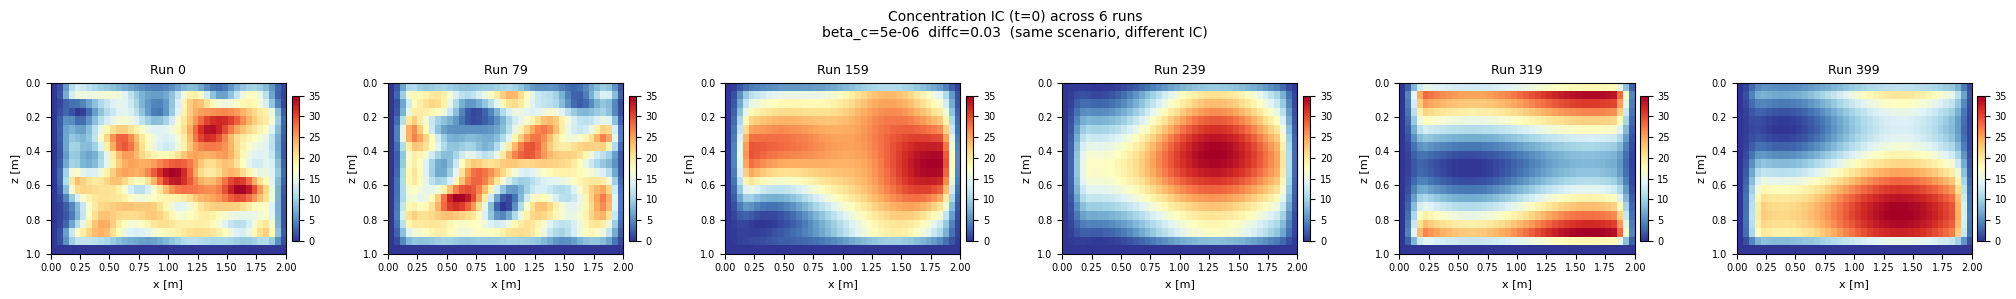

In [39]:
N_RUNS_SHOW = min(6, n_runs)   # how many runs to compare
T_IDX       = 0                # time step to compare at (0 = IC)

run_indices = np.linspace(0, n_runs - 1, N_RUNS_SHOW, dtype=int)

# Global colour limits across all runs for a fair comparison
all_conc = inp[run_indices, CONC_IN, T_IDX]   # (N_RUNS_SHOW, nlay, ncol)
c_vmin, c_vmax = float(all_conc.min()), float(all_conc.max())

fig, axes = plt.subplots(1, N_RUNS_SHOW, figsize=(3.4 * N_RUNS_SHOW, 3.0))
axes = np.atleast_1d(axes)

fig.suptitle(
    f'Concentration IC (t=0) across {N_RUNS_SHOW} runs\n'
    f'beta_c={beta_c}  diffc={diffc}  (same scenario, different IC)',
    fontsize=10,
)

for ax, run_idx in zip(axes, run_indices):
    field = inp[run_idx, CONC_IN, T_IDX]
    _imshow(ax, field, f'Run {run_idx}', 'RdYlBu_r', c_vmin, c_vmax)

plt.tight_layout()
plt.show()

## 6 · Target field statistics across runs

For the last target time step, compute the mean and standard deviation
of concentration and head across all runs. High variance indicates that
the initial condition strongly influences the long-term state.

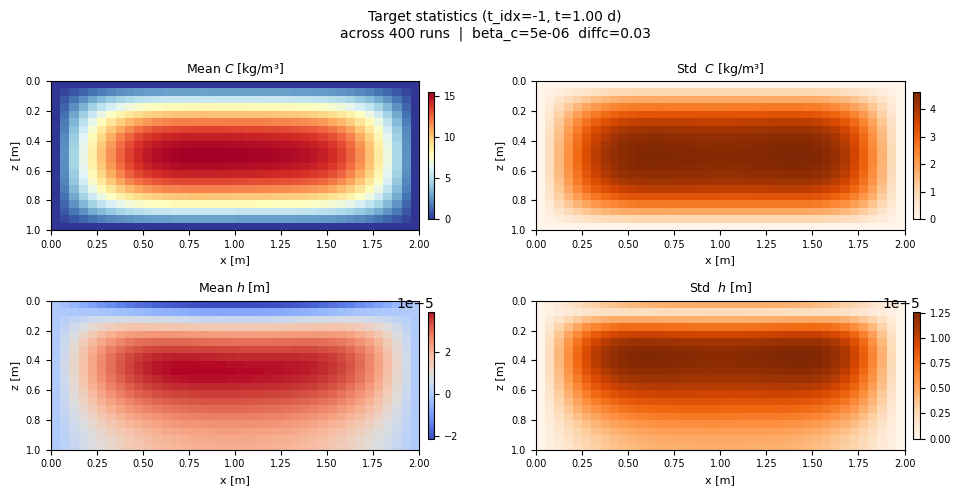

In [40]:
T_IDX_OUT = -1   # last output time step

conc_last = out[:, CONC_OUT, T_IDX_OUT]   # (n_runs, nlay, ncol)
head_last = out[:, HEAD_OUT, T_IDX_OUT]

conc_mean, conc_std = conc_last.mean(axis=0), conc_last.std(axis=0)
head_mean, head_std = head_last.mean(axis=0), head_last.std(axis=0)

fig, axes = plt.subplots(2, 2, figsize=(10, 5))
fig.suptitle(
    f'Target statistics (t_idx={T_IDX_OUT}, t={times_out[T_IDX_OUT]:.2f} d)\n'
    f'across {n_runs} runs  |  beta_c={beta_c}  diffc={diffc}',
    fontsize=10,
)

_imshow(axes[0, 0], conc_mean, r'Mean $C$ [kg/m³]', 'RdYlBu_r')
_imshow(axes[0, 1], conc_std,  r'Std  $C$ [kg/m³]', 'Oranges')
_imshow(axes[1, 0], head_mean, r'Mean $h$ [m]',     'coolwarm')
_imshow(axes[1, 1], head_std,  r'Std  $h$ [m]',     'Oranges')

plt.tight_layout()
plt.show()